# 👥 Employee Segmentation with K-Means

```text
Supervised:

Features → Target
   ↓         ↓
Employee → Promotion


Unsupervised:

Features
   ↓
K-Means
   ↓
Groups
```

No target here — K-Means finds groups of similar employees on its own.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Load the Data & Choose Features

In [2]:
df = pd.read_csv("./HR_comma_sep.csv")
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [3]:
features = [
    "satisfaction_level",
    "last_evaluation",
    "number_project",
    "average_montly_hours",
    "time_spend_company"
]
X = df[features]

## 2. Scaling

K-Means uses distances, so every feature must be on the same scale.

In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## 3. K-Means Clustering

In [5]:
from sklearn.cluster import KMeans

K = 4

kmeans = KMeans(
    n_clusters=K,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

In [6]:
df["cluster"] = clusters
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary,cluster
0,0.38,0.53,2,157,3,0,1,0,sales,low,0
1,0.80,0.86,5,262,6,0,1,0,sales,medium,2
2,0.11,0.88,7,272,4,0,1,0,sales,medium,1
3,0.72,0.87,5,223,5,0,1,0,sales,low,2
4,0.37,0.52,2,159,3,0,1,0,sales,low,0


## 4. Interpret the Clusters

The average of each feature per cluster describes each group.

In [7]:
df.groupby("cluster")[features].mean()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company
cluster,,,,,
0,0.479275,0.546210,2.722222,153.134585,3.143192
1,0.173199,0.807311,5.641457,247.961905,4.256022
2,0.753583,0.822191,4.204050,222.177051,6.178609
3,0.750441,0.754233,3.815133,209.003354,2.806815


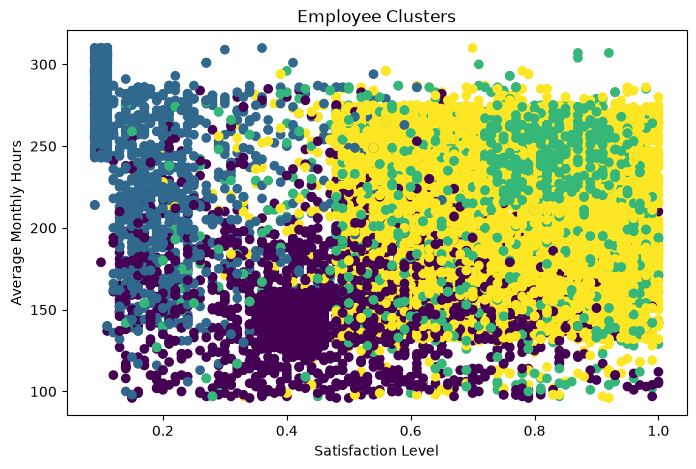

In [8]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["satisfaction_level"],
    df["average_montly_hours"],
    c=df["cluster"]
)

plt.xlabel("Satisfaction Level")
plt.ylabel("Average Monthly Hours")
plt.title("Employee Clusters")

plt.show()

## 5. Choosing K — Elbow Method & Silhouette Score

In [9]:
inertias = []

for k in range(2, 8):
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    km.fit(X_scaled)
    inertias.append(km.inertia_)

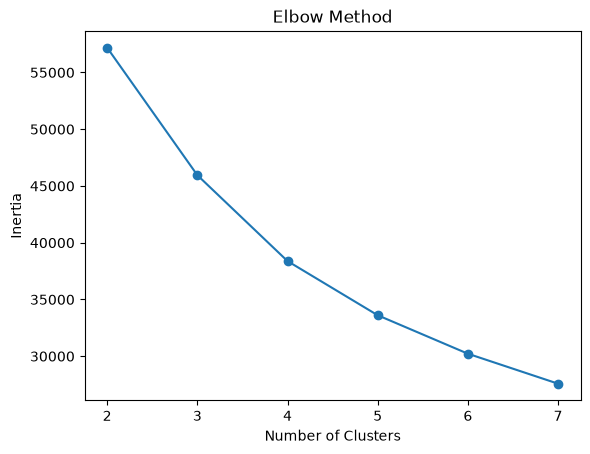

In [10]:
plt.plot(
    range(2, 8),
    inertias,
    marker="o"
)

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

In [11]:
from sklearn.metrics import silhouette_score

score = silhouette_score(
    X_scaled,
    df["cluster"]
)

print(f"Silhouette score for K={K}: {score:.3f}")

Silhouette score for K=4: 0.278
